In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_v3 import Bridge
from myDAQ_manager import logs_to_U

import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt

In [2]:
library_name = 'notch4test'
library = open_beam_library(library_name + '.json')
selection = ['B2', 'B1'] # U_in attached to B2
lib = sublibrary(selection, library)

R_ref = 98.4 # Ohm (B1)
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

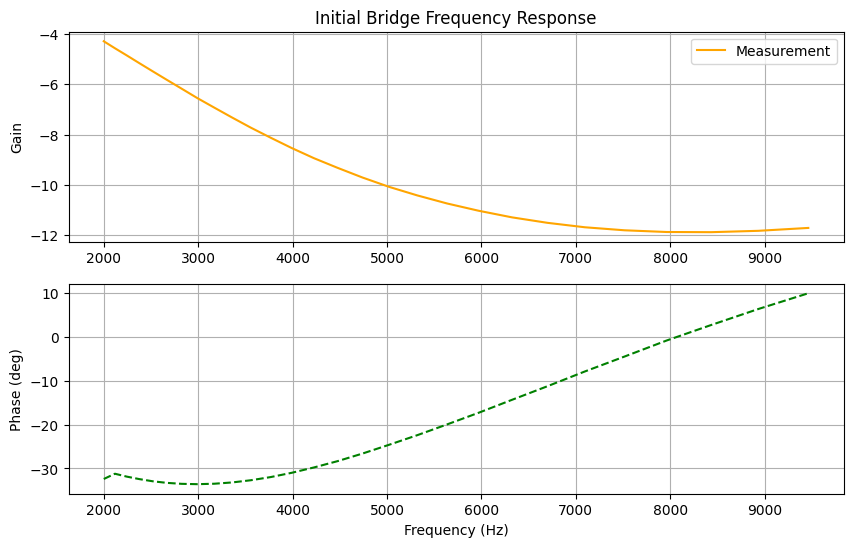

In [3]:
filename = 'resultaten1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

plt.figure(figsize=(10, 6))
# Plot Magnitude
plt.subplot(2, 1, 1)
plt.plot(f_arr_mes, 20*np.log10(gain_mes), color='orange', label='Measurement')
plt.ylabel('Gain')
plt.grid(True, which="both")
plt.legend()
plt.title('Initial Bridge Frequency Response')


# Plot Phase:
plt.subplot(2, 1, 2)
plt.plot(f_arr_mes, phase_mes, color='g', linestyle='--', label='Measurement')
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

In [4]:
# Import measurement logs:
filename = 'B2-B1-253-252ohm-2-10kHz-2.1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# Perform prediction:
R_def = [253, 253] # Initial resistance for our build filter!

R_pred = struc.predict_R(R_ref, myDAQ=True, f_arr_mes=f_arr_mes, U_out_mes=U_out_mes, resonance_sweep=False, 
                         error_plot=True, R_var=[0,1], R_def=R_def, response_comparison_plot=True)

print(f"The solver predicted {R_pred}, while the resistance values were {R_def}.")

AttributeError: 'Bridge' object has no attribute 'predict_R'

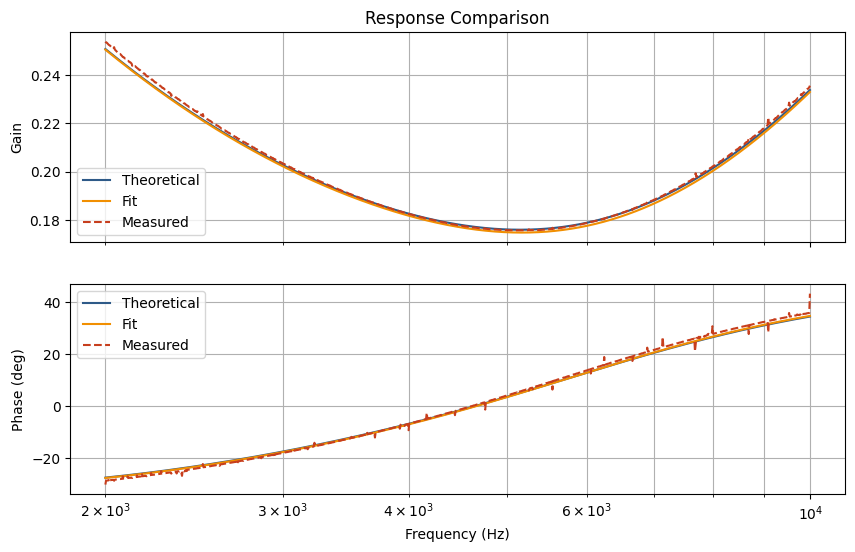

In [ ]:
U_th = struc.solve_U(f_arr_mes, R_ref, R_vec=R_def)
gain_th = np.abs(U_th)
phase_th = np.degrees(np.angle(U_th))

U_f = struc.solve_U(f_arr_mes, R_ref, R_vec=R_pred)
gain_f = np.abs(U_f)
phase_f = np.degrees(np.angle(U_f))

gain = [gain_th, gain_f, gain_mes]
phase = [phase_th, phase_f, phase_mes]

colors = ['#2E5A88', '#F18F01', '#C73E1D']
labels = ['Theoretical', 'Fit', 'Measured']
linestyles = ['-', '-', '--']

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for gain_i, phase_i, color, label, linestyle in zip(gain, phase, colors, labels, linestyles):
    ax[0].semilogx(f_arr_mes, gain_i, color=color, label=label, linestyle=linestyle)
    ax[1].semilogx(f_arr_mes, phase_i, color=color, label=label, linestyle=linestyle)

ax[0].set_ylabel('Gain')
ax[0].legend()
ax[0].grid(True, which='both')
ax[0].set_title('Response Comparison')
ax[1].set_ylabel('Phase (deg)')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].legend()
ax[1].grid(True, which='both')

In [ ]:
selection = ['A1','B2', 'B1'] # U_in attached to B2
lib = sublibrary(selection, library)

R_ref = 98.4 # Ohm (B1)
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0,2), (0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

Targeting 1 base features at (Hz): [8125.1]
Targeting 2 diff features at (Hz): [1158.5 8612.7]
R-values found, generating plot...
The solver predicted [250. 533. 253.], while the resistance values were [250, 533, 253]


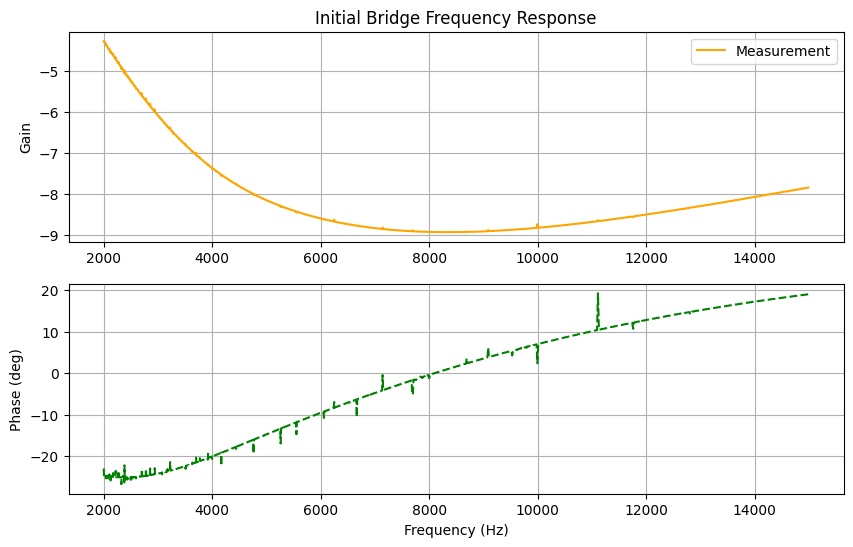

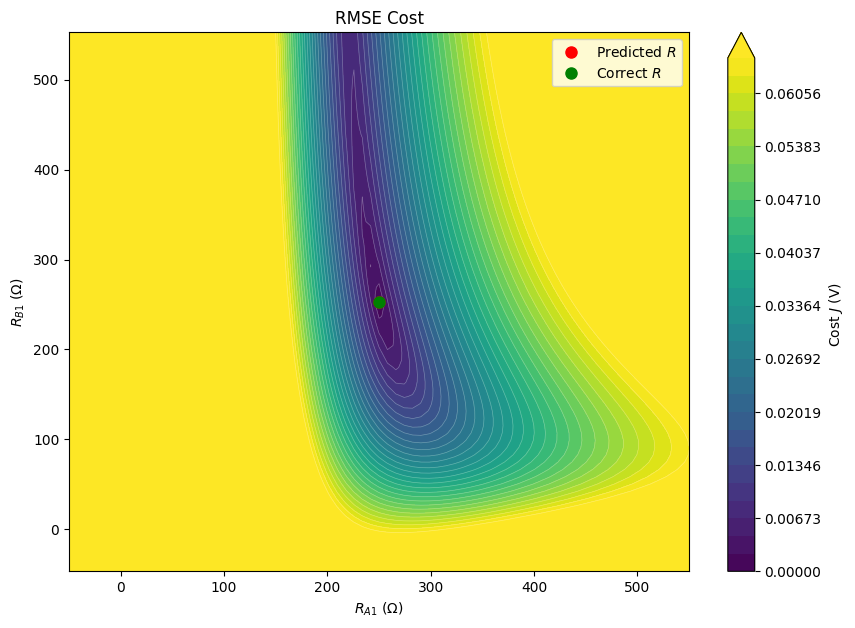

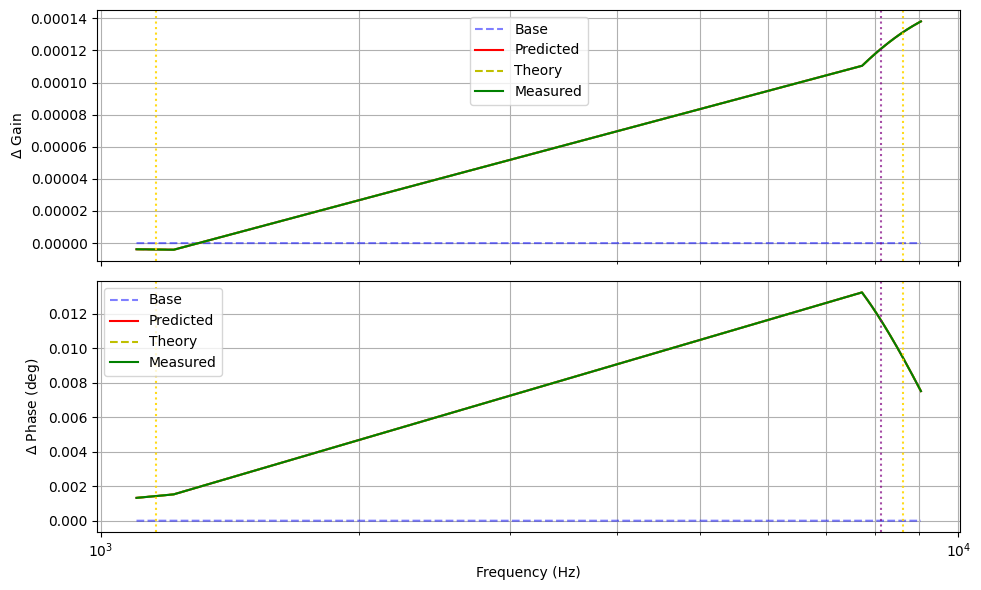

In [ ]:
# Import measurement logs:
filename = 'resultaten1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# filename = 'B2-B1-A1-253-753-533ohm-2-20kHz-2.1.txt'
# f_arr_mes2, gain_mes2, phase_mes2 = logs_to_U(filename, Cartesian=False)
# _, U_out_mes2 = logs_to_U(filename, Cartesian=True)

plt.figure(figsize=(10, 6))
# Plot Magnitude
plt.subplot(2, 1, 1)
plt.plot(f_arr_mes, 20*np.log10(gain_mes), color='orange', label='Measurement')
# plt.plot(f_arr_mes2, 20*np.log10(gain_mes2), color='g', linestyle='--', label='Measurement2')
plt.ylabel('Gain')
plt.grid(True, which="both")
plt.legend()
plt.title('Initial Bridge Frequency Response')


# Plot Phase:
plt.subplot(2, 1, 2)
plt.plot(f_arr_mes, phase_mes, color='g', linestyle='--', label='Measurement')
# plt.plot(f_arr_mes2, phase_mes2, color='orange', label='Measurement2')
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

# Perform prediction:
R_def = [250, 533, 253] # Initial resistance for our build filter!

R_pred = struc.predict_R(R_ref, myDAQ=False, f_arr_mes=f_arr_mes, U_out_mes=U_out_mes, resonance_sweep=True, 
                         error_plot=True, R_var=[0,2], R_def=R_def, response_comparison_plot=True)

print(f"The solver predicted {R_pred}, while the resistance values were {R_def}")

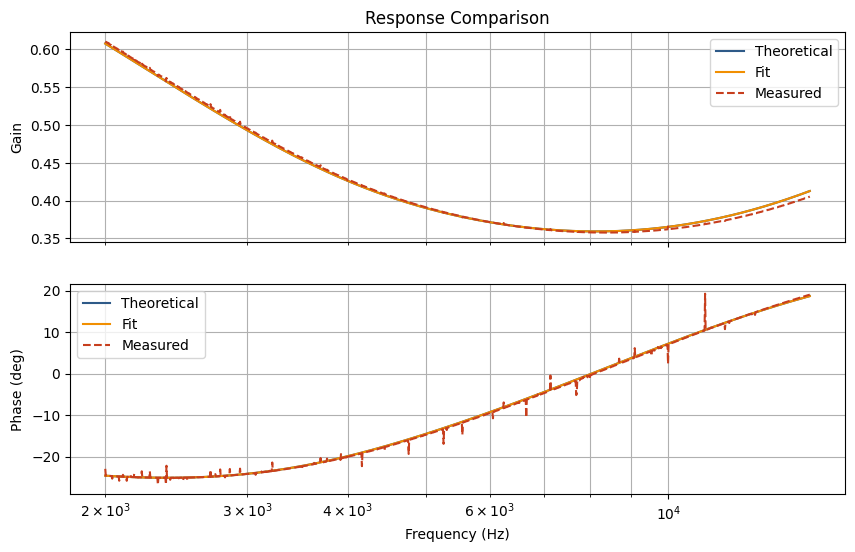

In [ ]:
U_th = struc.solve_U(f_arr_mes, R_ref, R_vec=R_def)
gain_th = np.abs(U_th)
phase_th = np.degrees(np.angle(U_th))

U_f = struc.solve_U(f_arr_mes, R_ref, R_vec=R_pred)
gain_f = np.abs(U_f)
phase_f = np.degrees(np.angle(U_f))

gain = [gain_th, gain_f, gain_mes]
phase = [phase_th, phase_f, phase_mes]

colors = ['#2E5A88', '#F18F01', '#C73E1D']
labels = ['Theoretical', 'Fit', 'Measured']
linestyles = ['-', '-', '--']

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for gain_i, phase_i, color, label, linestyle in zip(gain, phase, colors, labels, linestyles):
    ax[0].semilogx(f_arr_mes, gain_i, color=color, label=label, linestyle=linestyle)
    ax[1].semilogx(f_arr_mes, phase_i, color=color, label=label, linestyle=linestyle)

ax[0].set_ylabel('Gain')
ax[0].legend()
ax[0].grid(True, which='both')
ax[0].set_title('Response Comparison')
ax[1].set_ylabel('Phase (deg)')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].legend()
ax[1].grid(True, which='both')

TO-DO LIST:

Reinoud:
- Check Triangle again! Does it really work?
- Labview Downloaden
- Make it compatible for Macbook
- Format van de textfiles hetzelfde
- Test the MyDaq Sweep

Jules
- Include Correct Theoretical line in response_comparison_plot.
- Add Geometric Constraints